# LSTM Evaluation

In [25]:
import importlib
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import SmoothingFunction
import nltk
import sys
import time

nltk.download('wordnet')
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..', '..')))
import src.captioning.lstm.model as lstm_model_module
import src.captioning.rnn.model as rnn_model_module
importlib.reload(lstm_model_module)
importlib.reload(rnn_model_module)
from src.captioning.common.preprocessing import Tokenizer
from src.captioning.lstm.model import LSTMCaptioner
from src.captioning.rnn.model import RNNCaptioner
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, SimpleRNN, Reshape, Concatenate
from tensorflow.keras.models import Model

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Fayadh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [22]:
data_dir = "../../../data/flickr8k"
features = np.load(os.path.join(data_dir, "features.npy"))
with open(os.path.join(data_dir, "features_index.json"), 'r') as f:
    features_index = json.load(f)
tokenizer = Tokenizer.load(os.path.join(data_dir, "tokenizer.json"))
with open(os.path.join(data_dir, "splits.json"), 'r') as f:
    splits = json.load(f)

def load_captions(file_path, tokenizer):
    with open(file_path, 'r') as f: lines = f.readlines()[1:]
    mapping = {}
    for line in lines:
        parts = line.split(',', 1)
        if len(parts) < 2: continue
        img_id, cap = parts[0], parts[1].strip()
        if img_id not in mapping: mapping[img_id] = []
        clean_cap = tokenizer.clean_caption(cap)
        words = clean_cap.split()
        mapping[img_id].append(' '.join(words[1:-1]))
    return mapping
ground_truth_captions = load_captions(os.path.join(data_dir, "captions.txt"), tokenizer)

In [23]:
def define_lstm_keras_model(vocab_size, max_length, embed_dim, hidden_dim, num_layers=1):
    inputs1 = Input(shape=(2048,))
    fe1 = Dense(embed_dim, activation='relu', name='image_projection')(inputs1)
    fe1_reshaped = Reshape((1, embed_dim))(fe1)
    
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(inputs2)
    
    sequence_input = Concatenate(axis=1)([fe1_reshaped, se1])
    x = sequence_input
    for i in range(num_layers):
        x = LSTM(hidden_dim, return_sequences=True, name=f'lstm_{i}')(x)
        
    outputs = Dense(vocab_size, activation='softmax', name='dense_output')(x)
    return Model(inputs=[inputs1, inputs2], outputs=outputs)

def define_rnn_keras_model(vocab_size, max_length, embed_dim, hidden_dim, num_layers=1):
    inputs1 = Input(shape=(2048,))
    fe1 = Dense(embed_dim, activation='relu', name='image_projection')(inputs1)
    fe1_reshaped = Reshape((1, embed_dim))(fe1)
    
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(inputs2)
    
    sequence_input = Concatenate(axis=1)([fe1_reshaped, se1])
    x = sequence_input
    for i in range(num_layers):
        x = SimpleRNN(hidden_dim, return_sequences=True, name=f'simple_rnn_{i}')(x)
        
    outputs = Dense(vocab_size, activation='softmax', name='dense_output')(x)
    return Model(inputs=[inputs1, inputs2], outputs=outputs)

In [26]:
configs = [
    {"name": "lstm_1layer_128", "layers": 1, "hidden_dim": 128, "embed_dim": 256},
    {"name": "lstm_1layer_512", "layers": 1, "hidden_dim": 512, "embed_dim": 256},
    {"name": "lstm_2layer_128", "layers": 2, "hidden_dim": 128, "embed_dim": 256},
    {"name": "lstm_2layer_512", "layers": 2, "hidden_dim": 512, "embed_dim": 256},
    {"name": "lstm_3layer_128", "layers": 3, "hidden_dim": 128, "embed_dim": 256},
    {"name": "lstm_3layer_512", "layers": 3, "hidden_dim": 512, "embed_dim": 256},
]

results_lstm = {}
test_images = splits['test']
smooth_fn = SmoothingFunction().method1

print("--- Evaluasi Semua 6 Variasi LSTM (From-Scratch) ---")
for config in configs:
    keras_model = define_lstm_keras_model(
        tokenizer.vocab_size, tokenizer.max_length, 
        config['embed_dim'], config['hidden_dim'], config['layers']
    )
    keras_model.load_weights(f"../../../weights/captioning/lstm/{config['name']}.weights.h5")
    
    model = LSTMCaptioner(
        tokenizer.vocab_size, config['embed_dim'], 
        config['hidden_dim'], tokenizer.max_length,
        num_layers=config['layers']
    )
    model.load_weights_from_keras(keras_model)
    
    actuals, preds = [], []
    meteor_scores = []
    
    start_time = time.time()
    for img_id in test_images[:100]:
        feature = features[features_index[img_id]].reshape(1, -1)
        cap = model.generate_caption_greedy(feature, tokenizer)
        
        gt = ground_truth_captions.get(img_id, [])
        actuals.append([g.split() for g in gt])
        
        p = cap.split()
        preds.append(p)
        best_meteor = max([meteor_score([g.split()], p) for g in gt]) if gt else 0
        meteor_scores.append(best_meteor)
        
    exec_time = time.time() - start_time
    bleu4 = corpus_bleu(actuals, preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)
    meteor = np.mean(meteor_scores) if meteor_scores else 0
    
    results_lstm[config['name']] = {'bleu4': bleu4, 'meteor': meteor, 'time': exec_time}
    print(f"{config['name']:<15} | BLEU-4: {bleu4:.4f} | METEOR: {meteor:.4f} | Time: {exec_time:.2f}s")

--- Evaluasi Semua 6 Variasi LSTM (From-Scratch) ---
lstm_1layer_128 | BLEU-4: 0.0548 | METEOR: 0.2521 | Time: 13.97s
lstm_1layer_512 | BLEU-4: 0.0898 | METEOR: 0.2619 | Time: 32.08s
lstm_2layer_128 | BLEU-4: 0.0743 | METEOR: 0.2586 | Time: 6.49s
lstm_2layer_512 | BLEU-4: 0.0583 | METEOR: 0.2191 | Time: 60.34s
lstm_3layer_128 | BLEU-4: 0.0212 | METEOR: 0.1887 | Time: 18.42s
lstm_3layer_512 | BLEU-4: 0.0924 | METEOR: 0.2880 | Time: 59.63s


In [27]:
best_lstm_name = max(results_lstm, key=lambda k: results_lstm[k]['bleu4'])
best_lstm_config = next(c for c in configs if c['name'] == best_lstm_name)

print(f"\n--- Arsitektur Terbaik LSTM: {best_lstm_name} ---")

keras_lstm_best = define_lstm_keras_model(
    tokenizer.vocab_size, tokenizer.max_length, 
    best_lstm_config['embed_dim'], best_lstm_config['hidden_dim'], best_lstm_config['layers']
)
keras_lstm_best.load_weights(f"../../../weights/captioning/lstm/{best_lstm_config['name']}.weights.h5")

lstm_scratch_best = LSTMCaptioner(
    tokenizer.vocab_size, best_lstm_config['embed_dim'], 
    best_lstm_config['hidden_dim'], tokenizer.max_length,
    num_layers=best_lstm_config['layers']
)
lstm_scratch_best.load_weights_from_keras(keras_lstm_best)

def generate_caption_keras_generic(model, tokenizer, image_feature, max_length):
    in_text = tokenizer.start_token
    for _ in range(max_length):
        sequence = [tokenizer.word_index[w] for w in in_text.split() if w in tokenizer.word_index]
        sequence = np.pad(sequence, (0, max_length - len(sequence)), 'constant', constant_values=tokenizer.word_index[tokenizer.pad_token])
        
        yhat = model.predict([image_feature, np.array([sequence])], verbose=0)
        curr_step = len(in_text.split())
        word_idx = np.argmax(yhat[0, curr_step])
        word = tokenizer.index_word.get(word_idx, '')
        
        if word == tokenizer.end_token or word == tokenizer.pad_token:
            break
        in_text += ' ' + word
        
    return ' '.join(in_text.split()[1:])

keras_lstm_preds = []
keras_lstm_actuals = []
start_time = time.time()

for img_id in test_images[:100]:
    feature = features[features_index[img_id]].reshape(1, -1)
    cap = generate_caption_keras_generic(keras_lstm_best, tokenizer, feature, tokenizer.max_length)
    keras_lstm_preds.append(cap.split())
    gt = ground_truth_captions.get(img_id, [])
    keras_lstm_actuals.append([g.split() for g in gt])
    
keras_lstm_time = time.time() - start_time
keras_lstm_bleu = corpus_bleu(keras_lstm_actuals, keras_lstm_preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)

print(f"BLEU-4 (LSTM Scratch): {results_lstm[best_lstm_name]['bleu4']:.4f} | Time: {results_lstm[best_lstm_name]['time']:.2f}s")
print(f"BLEU-4 (LSTM Keras):   {keras_lstm_bleu:.4f} | Time: {keras_lstm_time:.2f}s")


--- Arsitektur Terbaik LSTM: lstm_3layer_512 ---
BLEU-4 (LSTM Scratch): 0.0924 | Time: 59.63s
BLEU-4 (LSTM Keras):   0.0959 | Time: 368.14s



--- RNN vs LSTM Qualitative Analysis (10 Images) ---


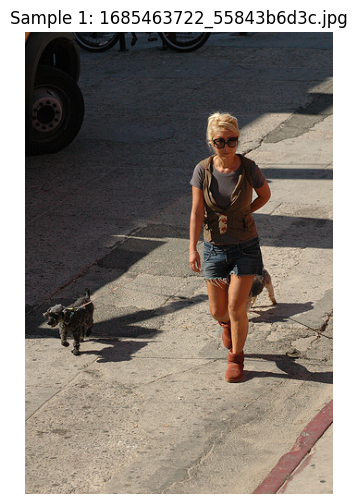

[Sample 1]
Ground Truths: ['a woman and her two dogs are walking down the street', 'a woman wearing cut off shorts walks down the street with a dog', 'the woman in blue shorts and a brown vest has a black dog to the right of her and a dog behind her', 'the woman is walking her dogs', 'woman and small black dog walking across pavement']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a red and white dog
--------------------------------------------------------------------------------


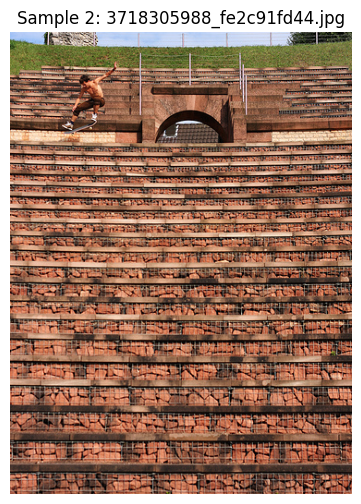

[Sample 2]
Ground Truths: ['a jogger runs up brick stairs for streght training', 'a man is skating down a set of stairs', 'a skateboarder jumps on brick stairs', 'a young man skateboards around the empty outdoor sports arena', 'the man is skateboarding on a large brick staircase']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a red and white dog
--------------------------------------------------------------------------------


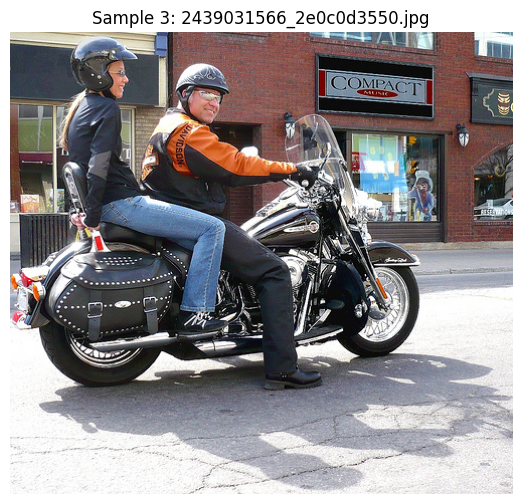

[Sample 3]
Ground Truths: ['a couple riding a bike', 'a couple riding down the street on a motorcycle', 'a man and woman sitting on a motorcycle', 'a man sits on a motorcycle and a woman is on the back', 'two people ride together on a black motorcycle']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


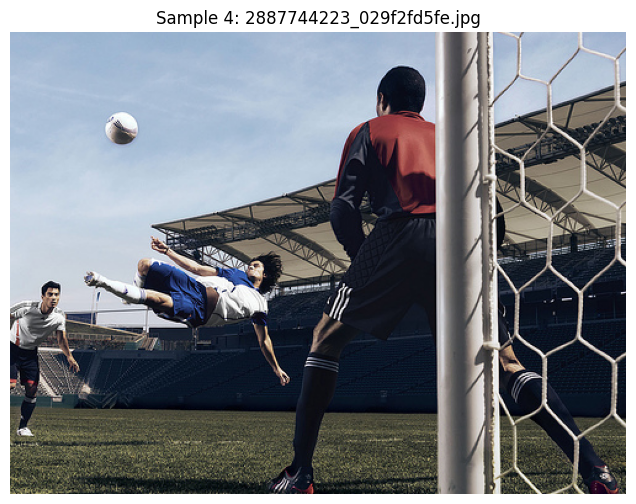

[Sample 4]
Ground Truths: ['a man is parallel in the air trying to kick the soccer ball past the goalie', 'a soccer player in white attacks the ball with flying kick towards the goal of the player in red as another team member looks on', 'a soccer player is jumping into the air to kick the soccer ball into the goal', 'a soccer player is making a flying kick towards the goal', 'a soccer player leaps sideways in the air to kick the ball']
RNN Caption:   a dog is running through the water
LSTM Caption:  a man in a red shirt is standing on a red and white dog
--------------------------------------------------------------------------------


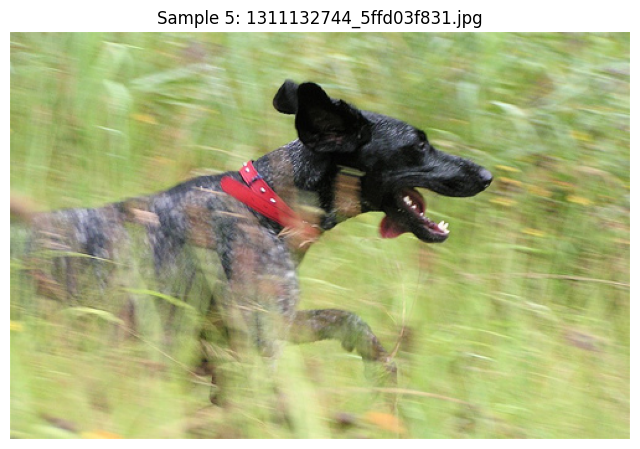

[Sample 5]
Ground Truths: ['a black and grey dog runs in a field with its tongue hanging out', 'a black dog with a red collar runs through grass', 'a black dog with a red collar walks through the grass with his mouth open and tongue hanging out', 'a dog with a red collar and its tongue hanging out runs through tall grass', 'a dog with red collar is running in the field']
RNN Caption:   a dog is running through the water
LSTM Caption:  a dog is running through the grass
--------------------------------------------------------------------------------


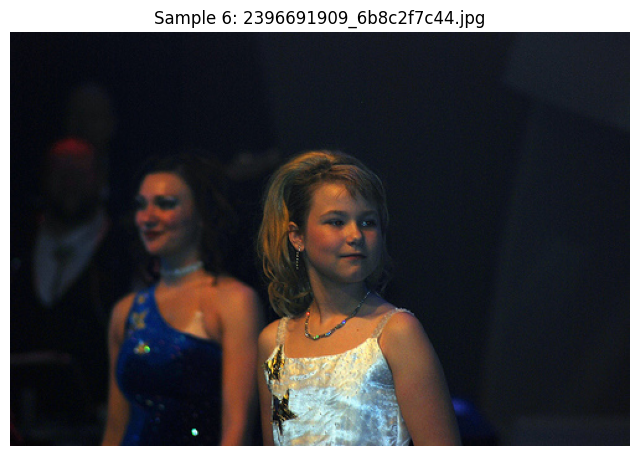

[Sample 6]
Ground Truths: ['a girl in a white dress walks next to a girl in a blue dress', 'a woman in a white dress and a woman in a blue dress onstage', 'a young girl with makeup and jewelry smiles', 'blonde girl in white top with stars standing beside brunette woman in blue top with stars', 'two teenage girls are wearing fancy dresses at an event']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a swing
--------------------------------------------------------------------------------


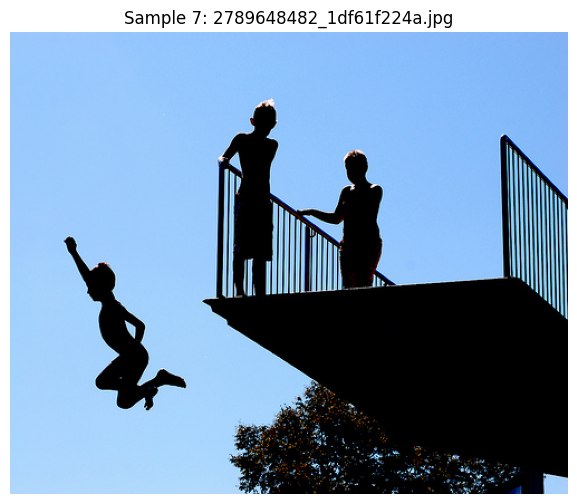

[Sample 7]
Ground Truths: ['a boy jumps off a platform whilst two other boys stand and watch', 'a child is jumping off a platform into a pool', 'three boys jumping off of a platform', 'three children on diving board with one jumping off', 'two boys standing on top of a diving platform and one captured midair']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


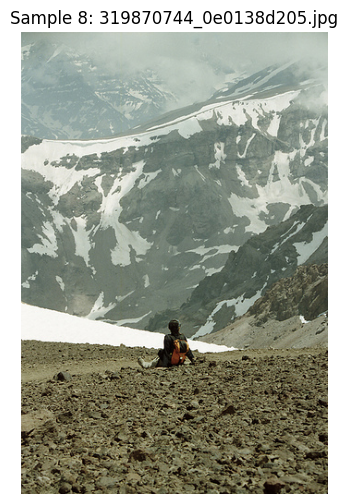

[Sample 8]
Ground Truths: ['a hiker is sitting on the ground looking towards the snow covered mountains', 'a man is sitting on top of a mountain', 'a person sits near a mountain', 'one person wearing a backpack sitting on the side of a rocky mountain', 'someone is sitting on a hill overlooking a rocky mountain']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a bench
--------------------------------------------------------------------------------


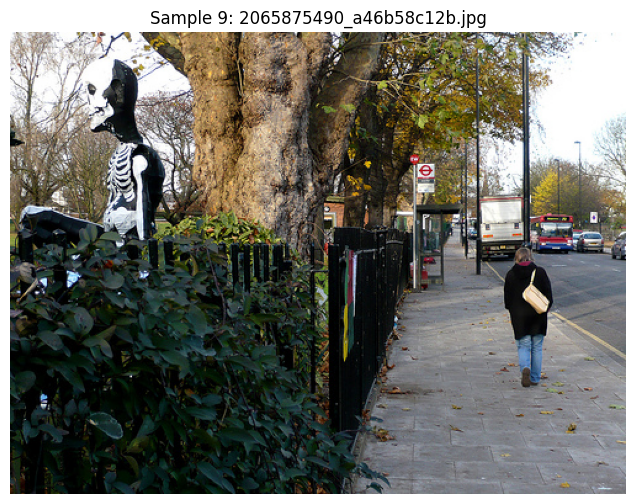

[Sample 9]
Ground Truths: ['a person is walking on a sidewalk and a skeleton is on the left inside of a fence', 'a skeleton sits on a fence on the edge of a road', 'a skeleton sits on the bushes', 'a woman walks down a sidewalk past a halloween decoration', 'there is a large skeleton behind a fence']
RNN Caption:   a man in a red shirt is standing on a bench
LSTM Caption:  a man in a red shirt is standing on a red and white dog
--------------------------------------------------------------------------------


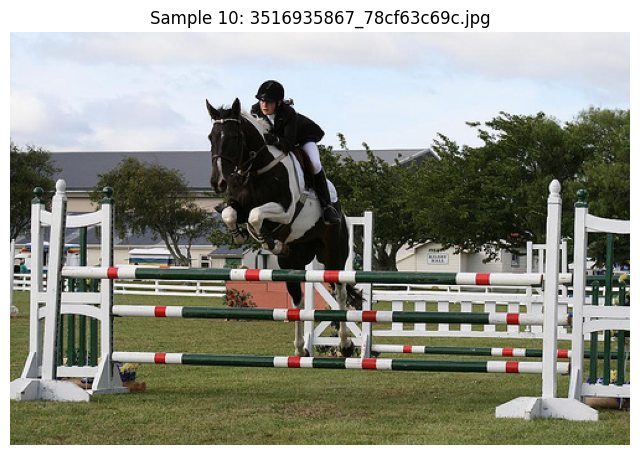

[Sample 10]
Ground Truths: ['a black horse and its rider are clearing a 3 rung high jump in a competition', 'a horse and rider leap over a striped hurdle', 'a person is riding a horse as it jumps over an obstacle', 'a person jumping a horse over a fence', 'a rider and horse jumping a fence outdoors']
RNN Caption:   a dog is running through the water
LSTM Caption:  a man in a red shirt is standing on a red and white dog
--------------------------------------------------------------------------------


In [ ]:
print("\n--- RNN vs LSTM Qualitative Analysis (10 Images) ---")

best_rnn_name = "rnn_2layer_128"

def parse_rnn_config(name):
    parts = name.split("_")
    if len(parts) != 3 or not parts[1].endswith("layer") or not parts[2].isdigit():
        raise ValueError(f"Invalid RNN checkpoint name format: {name}")
    layers = int(parts[1].replace("layer", ""))
    hidden_dim = int(parts[2])
    return {"name": name, "layers": layers, "hidden_dim": hidden_dim, "embed_dim": 256}

best_rnn_config = parse_rnn_config(best_rnn_name)
rnn_weights_path = f"../../../weights/captioning/rnn/{best_rnn_config['name']}.weights.h5"
if not os.path.exists(rnn_weights_path):
    raise FileNotFoundError(f"RNN weights not found: {rnn_weights_path}")

keras_rnn_best = define_rnn_keras_model(
    tokenizer.vocab_size, tokenizer.max_length,
    best_rnn_config['embed_dim'], best_rnn_config['hidden_dim'], best_rnn_config['layers']
)
keras_rnn_best.load_weights(rnn_weights_path)

rnn_scratch_best = RNNCaptioner(
    tokenizer.vocab_size, best_rnn_config['embed_dim'],
    best_rnn_config['hidden_dim'], tokenizer.max_length, best_rnn_config['layers']
)
rnn_scratch_best.load_weights_from_keras(keras_rnn_best)

for idx, img_id in enumerate(splits['test'][:10]):
    feature = features[features_index[img_id]].reshape(1, -1)

    cap_rnn = rnn_scratch_best.generate_caption(feature, tokenizer)
    cap_lstm = lstm_scratch_best.generate_caption_greedy(feature, tokenizer)
    gt = ground_truth_captions.get(img_id, [])

    img_path = os.path.join(data_dir, "images", img_id)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample {idx+1}: {img_id}")
        plt.show()

    print(f"[Sample {idx+1}]")
    print(f"Ground Truths: {gt}")
    print(f"RNN Caption:   {cap_rnn}")
    print(f"LSTM Caption:  {cap_lstm}")
    print("-" * 80)


--- RNN vs LSTM Full Comparison (100 Test Images) ---
Metric          | RNN             | LSTM           
--------------------------------------------------
BLEU-4          | 0.1168          | 0.0924         
METEOR          | 0.2938          | 0.2880         
Exec Time (s)   | 7.60            | 70.99          


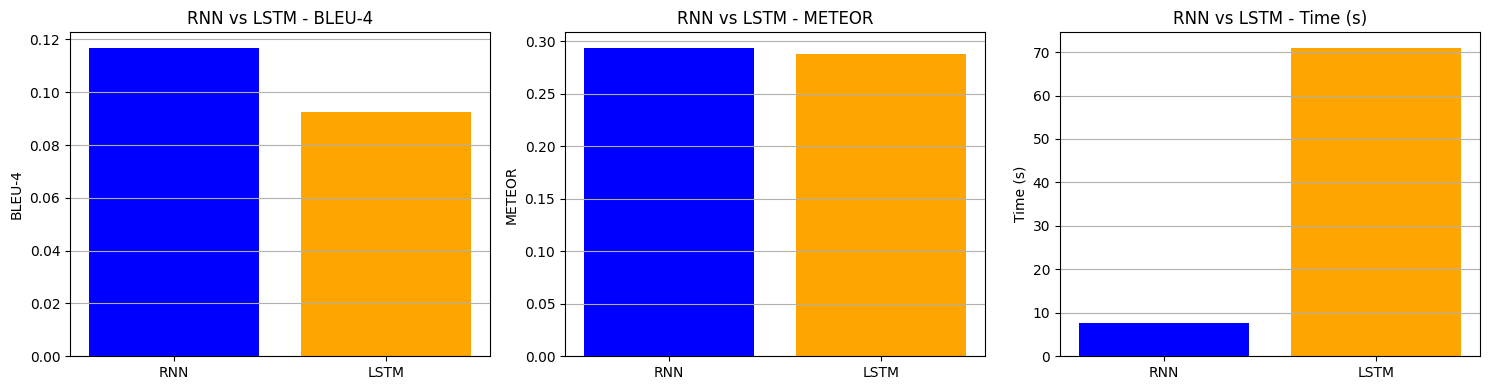

In [31]:
print("\n--- RNN vs LSTM Full Comparison (100 Test Images) ---")

rnn_preds, rnn_actuals, rnn_meteors = [], [], []
lstm_preds, lstm_actuals, lstm_meteors = [], [], []

rnn_start = time.time()
for img_id in test_images[:100]:
    feature = features[features_index[img_id]].reshape(1, -1)
    cap = rnn_scratch_best.generate_caption(feature, tokenizer)
    rnn_preds.append(cap.split())
    
    gt = ground_truth_captions.get(img_id, [])
    rnn_actuals.append([g.split() for g in gt])
    rnn_m = max([meteor_score([g.split()], cap.split()) for g in gt]) if gt else 0
    rnn_meteors.append(rnn_m)
rnn_time = time.time() - rnn_start

lstm_start = time.time()
for img_id in test_images[:100]:
    feature = features[features_index[img_id]].reshape(1, -1)
    cap = lstm_scratch_best.generate_caption_greedy(feature, tokenizer)
    lstm_preds.append(cap.split())
    
    gt = ground_truth_captions.get(img_id, [])
    lstm_actuals.append([g.split() for g in gt])
    lstm_m = max([meteor_score([g.split()], cap.split()) for g in gt]) if gt else 0
    lstm_meteors.append(lstm_m)
lstm_time = time.time() - lstm_start

rnn_bleu = corpus_bleu(rnn_actuals, rnn_preds, weights=(0.25, 0.25, 0.25, 0.25))
lstm_bleu = corpus_bleu(lstm_actuals, lstm_preds, weights=(0.25, 0.25, 0.25, 0.25))
rnn_meteor = np.mean(rnn_meteors)
lstm_meteor = np.mean(lstm_meteors)

print(f"{'Metric':<15} | {'RNN':<15} | {'LSTM':<15}")
print(f"{'-'*50}")
print(f"{'BLEU-4':<15} | {rnn_bleu:<15.4f} | {lstm_bleu:<15.4f}")
print(f"{'METEOR':<15} | {rnn_meteor:<15.4f} | {lstm_meteor:<15.4f}")
print(f"{'Exec Time (s)':<15} | {rnn_time:<15.2f} | {lstm_time:<15.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['BLEU-4', 'METEOR', 'Time (s)']
rnn_vals = [rnn_bleu, rnn_meteor, rnn_time]
lstm_vals = [lstm_bleu, lstm_meteor, lstm_time]

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    ax.bar(['RNN', 'LSTM'], [rnn_vals[i], lstm_vals[i]], color=['blue', 'orange'])
    ax.set_ylabel(metric)
    ax.set_title(f'RNN vs LSTM - {metric}')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()


--- Pengaruh Panjang Maksimum Caption pada BLEU-4 ---
Max Length 10 -> BLEU-4: 0.1193
Max Length 15 -> BLEU-4: 0.0956
Max Length 20 -> BLEU-4: 0.0945
Max Length 38 -> BLEU-4: 0.0924


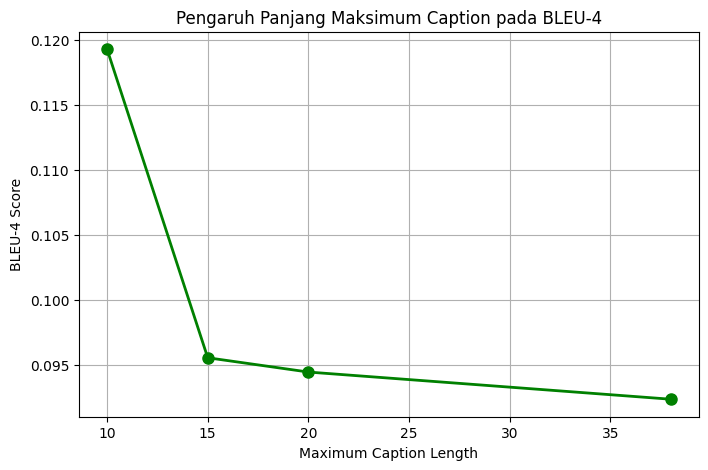

In [32]:
print("\n--- Pengaruh Panjang Maksimum Caption pada BLEU-4 ---")
max_lengths_to_test = [10, 15, 20, tokenizer.max_length]

length_results = {}
for m_len in max_lengths_to_test:
    preds = []
    actuals = []
    
    lstm_scratch_best.max_length = m_len
    
    for img_id in splits['test'][:100]:
        feature = features[features_index[img_id]].reshape(1, -1)
        cap = lstm_scratch_best.generate_caption_greedy(feature, tokenizer, max_length=m_len)
        preds.append(cap.split())
        
        gt = ground_truth_captions.get(img_id, [])
        actuals.append([g.split() for g in gt])
        
    bleu = corpus_bleu(actuals, preds, weights=(0.25, 0.25, 0.25, 0.25))
    length_results[m_len] = bleu
    print(f"Max Length {m_len:>2} -> BLEU-4: {bleu:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(length_results.keys()), list(length_results.values()), marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Maximum Caption Length')
plt.ylabel('BLEU-4 Score')
plt.title('Pengaruh Panjang Maksimum Caption pada BLEU-4')
plt.grid(True)
plt.show()

lstm_scratch_best.max_length = tokenizer.max_length